<div style="border: 1px solid black">
<b><center><font size="5">“ChromaTruth”: Deteção de Deepfakes através de
Inconsistências na Reconstrução Cromática</font></center></b>

<b><center><font size="3">
</font></center></b>
</div>


---
`Nome:` **Carolina Raposo** <br>
`Número:` **51601**<br>
`Email:` **carolina.reis.raposo@ubi.pt**<br>
`Curso:` **Inteligência Artificial e Ciência de Dados** <br>
`Disciplina:` **Redes Neuronais e Aprendizagem Profunda 2025/2026**<br>


---



# Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ==========================================
# IMPORTS GERAIS DO PROJETO CHROMATRUTH
# ==========================================

import os
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

from PIL import Image, ImageDraw, ImageChops, ImageFilter
from skimage import color

import matplotlib.pyplot as plt
import cv2

from diffusers import StableDiffusionInpaintPipeline

from sklearn.metrics import roc_curve, auc

from tqdm import tqdm

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [7]:
REAL_DIR = "/content/drive/MyDrive/Colab Notebooks/RNAP/TP2/data/real"
FAKE_DIR = "/content/drive/MyDrive/Colab Notebooks/RNAP/TP2/data/fake"
MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/RNAP/TP2/models/unet_chroma_truth.pth"

IMG_SIZE = 256

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# Fase 1: O “Adversário” (Geração de Dados)

Device: cuda


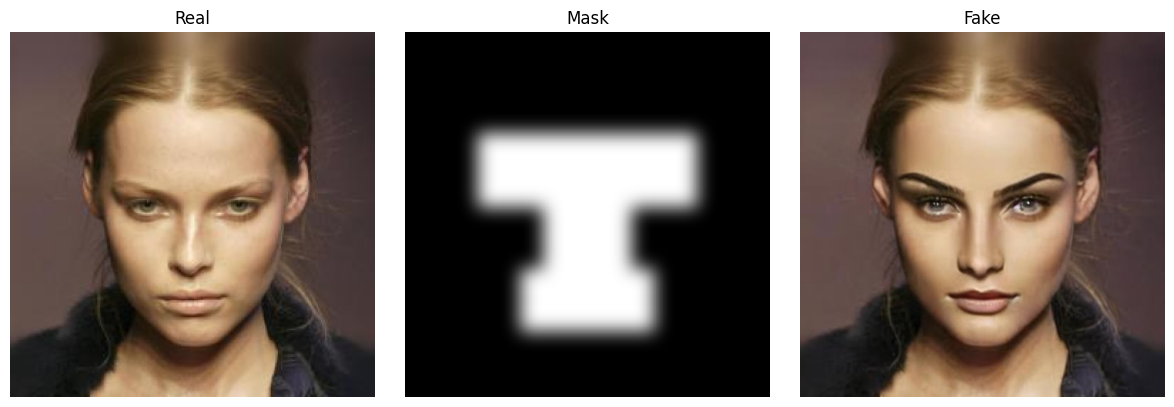

In [25]:
# ==========================================
# GERAÇÃO DOS DEEPFAKES
# ==========================================

NUM_DEEPFAKES = 6000
NUM_PREVIEW = 1

# MODO_VISUALIZACAO = True  -> só visualizar imagens já existentes
# MODO_VISUALIZACAO = False -> gerar deepfakes + visualizar
MODO_VISUALIZACAO = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

pipe = None

if not MODO_VISUALIZACAO:
    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        "runwayml/stable-diffusion-inpainting",
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        safety_checker=None
    ).to(DEVICE)

PROMPT = (
    "realistic human face, same identity, "
    "subtle but noticeable changes in facial features, "
    "slightly different eyes shape, nose proportions or lips contour, "
    "natural skin texture, realistic lighting, high detail"
)

NEGATIVE_PROMPT = (
    "cartoon, anime, painting, blur, distortion, "
    "deformed face, extra eyes, extra mouth, bad anatomy"
)

def facial_regions(w, h):
    return {
        "eyes":  (int(0.20*w), int(0.28*h), int(0.80*w), int(0.48*h)),
        "nose":  (int(0.38*w), int(0.45*h), int(0.62*w), int(0.70*h)),
        "mouth": (int(0.32*w), int(0.65*h), int(0.68*w), int(0.82*h)),
    }

def create_combined_mask(image):
    w, h = image.size
    regions = facial_regions(w, h)

    chosen = random.sample(list(regions.keys()), random.randint(2, 3))

    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    for r in chosen:
        draw.rectangle(regions[r], fill=255)

    mask = mask.filter(ImageFilter.GaussianBlur(radius=6))
    return mask

def visualize(real, mask, fake):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(real)
    plt.title("Real")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(fake)
    plt.title("Fake")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def image_difference(img1, img2):
    diff = ImageChops.difference(img1, img2)
    return np.mean(np.array(diff))

if not MODO_VISUALIZACAO:
    os.makedirs(FAKE_DIR, exist_ok=True)

    all_files = sorted(os.listdir(REAL_DIR))
    assert len(all_files) >= NUM_DEEPFAKES

    selected_files = random.sample(all_files, NUM_DEEPFAKES)

    for i, fname in enumerate(selected_files):
        print(f"[{i+1}/{NUM_DEEPFAKES}] {fname}", end="\r")

        img_path = os.path.join(REAL_DIR, fname)
        image = Image.open(img_path).convert("RGB")

        mask = create_combined_mask(image)

        for _ in range(2):
            with torch.no_grad():
                fake = pipe(
                    prompt=PROMPT,
                    negative_prompt=NEGATIVE_PROMPT,
                    image=image,
                    mask_image=mask,
                    num_inference_steps=35,
                    guidance_scale=9.0
                ).images[0]

            if image_difference(image, fake) > 6.0:
                break

        fake.save(os.path.join(FAKE_DIR, fname))

    print("\nDeepfakes geradas com sucesso.")


fake_files = set(os.listdir(FAKE_DIR))
real_files = set(os.listdir(REAL_DIR))

# apenas ficheiros que existem nos dois lados
common_files = sorted(fake_files.intersection(real_files))

assert len(common_files) > 0, "Não há pares real/fake correspondentes."

preview = random.sample(common_files, min(NUM_PREVIEW, len(common_files)))

for fname in preview:
    real = Image.open(os.path.join(REAL_DIR, fname)).convert("RGB")
    fake = Image.open(os.path.join(FAKE_DIR, fname)).convert("RGB")

    mask = create_combined_mask(real)
    visualize(real, mask, fake)

#  Fase 2: O “Detetive Cromático” (Modelo de Autoencoder)

Device: cuda


Epoch 1/15 [Train]: 100%|██████████| 387/387 [07:46<00:00,  1.20s/it]


Loss — Train: 0.0605 | Val: 0.0525


Epoch 2/15 [Train]: 100%|██████████| 387/387 [05:47<00:00,  1.11it/s]


Loss — Train: 0.0505 | Val: 0.0513


...

Loss — Train: 0.0459 | Val: 0.0464


Epoch 14/15 [Train]: 100%|██████████| 387/387 [05:48<00:00,  1.11it/s]


Loss — Train: 0.0458 | Val: 0.0479


Epoch 15/15 [Train]: 100%|██████████| 387/387 [05:49<00:00,  1.11it/s]


Loss — Train: 0.0455 | Val: 0.0471


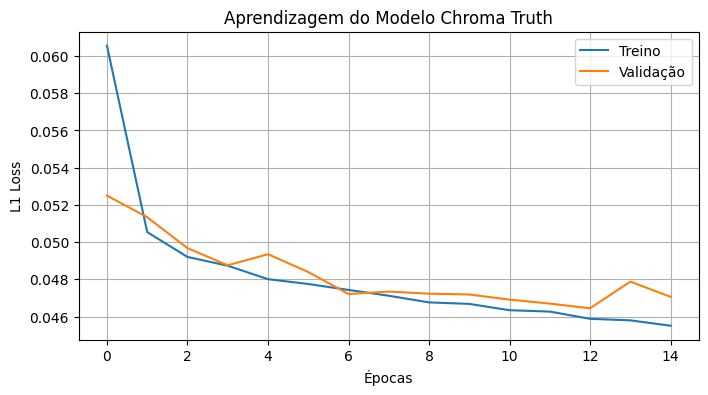

In [3]:
BATCH_SIZE = 16
EPOCHS = 15
LR = 2e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ==========================================
# DATASET — IMAGENS REAIS EM ESPAÇO LAB
# ==========================================

class FaceColorDataset(Dataset):
    def __init__(self, root_dir):
        self.files = sorted([
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        img = self.transform(img)

        img_np = img.permute(1, 2, 0).numpy()
        lab = color.rgb2lab(img_np)

        # Normalização conforme Zhang et al.
        L  = lab[:, :, 0:1] / 100.0
        ab = lab[:, :, 1:] / 128.0

        L  = torch.from_numpy(L).permute(2, 0, 1).float()
        ab = torch.from_numpy(ab).permute(2, 0, 1).float()

        return L, ab

# ==========================================
# DATALOADERS
# ==========================================

dataset = FaceColorDataset(REAL_DIR)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# ARQUITETURA U-NET
# ==========================================

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.down1 = DoubleConv(1, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 2, 1)

    def forward(self, x):
        c1 = self.down1(x)
        c2 = self.down2(self.pool(c1))
        c3 = self.down3(self.pool(c2))
        c4 = self.down4(self.pool(c3))

        u3 = self.up3(c4)
        u3 = self.conv3(torch.cat([u3, c3], dim=1))

        u2 = self.up2(u3)
        u2 = self.conv2(torch.cat([u2, c2], dim=1))

        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, c1], dim=1))

        return self.final(u1)

# ==========================================
# TREINO
# ==========================================

model = UNet().to(DEVICE)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_loss_hist = []
val_loss_hist = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for L, ab in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        L, ab = L.to(DEVICE), ab.to(DEVICE)

        optimizer.zero_grad()
        pred = model(L)
        loss = criterion(pred, ab)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for L, ab in val_loader:
            L, ab = L.to(DEVICE), ab.to(DEVICE)
            pred = model(L)
            val_loss += criterion(pred, ab).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)

    print(f"Loss — Train: {train_loss:.4f} | Val: {val_loss:.4f}")

# ==========================================
# RESULTADOS
# ==========================================

torch.save(model.state_dict(), MODEL_PATH)

plt.figure(figsize=(8, 4))
plt.plot(train_loss_hist, label="Treino")
plt.plot(val_loss_hist, label="Validação")
plt.xlabel("Épocas")
plt.ylabel("L1 Loss")
plt.title("Aprendizagem do Modelo Chroma Truth")
plt.legend()
plt.grid(True)
plt.show()

# Fase 3: Deteção e Explicabilidade (XAI)


Fakes: 100%|██████████| 5592/5592 [05:52<00:00, 15.87it/s]


AUC: 0.5318
Threshold ótimo: 0.0505


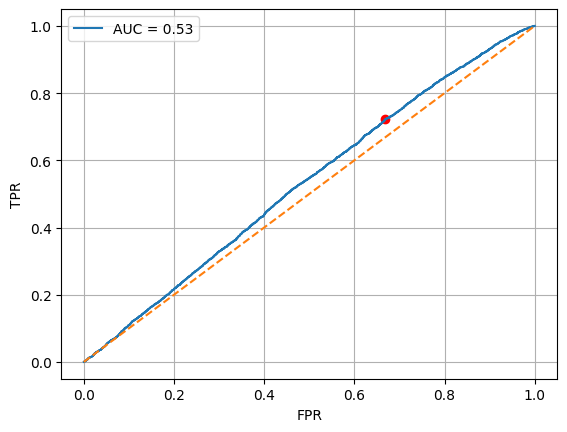

Gerando heatmaps (falsas): 100%|██████████| 5592/5592 [09:48<00:00,  9.50it/s]

Heatmaps gerados para todas as imagens falsas.


In [12]:
# ==========================================
# ARQUITETURA UNET
# ==========================================

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNetDeep(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.down1 = DoubleConv(1, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 2, 1)

    def forward(self, x):
        c1 = self.down1(x)
        c2 = self.down2(self.pool(c1))
        c3 = self.down3(self.pool(c2))
        c4 = self.down4(self.pool(c3))

        u3 = self.up3(c4)
        u3 = self.conv3(torch.cat([u3, c3], dim=1))

        u2 = self.up2(u3)
        u2 = self.conv2(torch.cat([u2, c2], dim=1))

        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, c1], dim=1))

        return self.final(u1)

# ==========================================
# HEATMAP E ERRO
# ==========================================

def get_heatmap(L, ab_real, ab_pred):
    error_map = torch.sqrt(torch.sum((ab_real - ab_pred) ** 2, dim=0)).cpu().numpy()

    error_norm = cv2.normalize(error_map, None, 0, 255, cv2.NORM_MINMAX)
    heatmap = cv2.applyColorMap(error_norm.astype(np.uint8), cv2.COLORMAP_JET)

    L_np = (L.squeeze().cpu().numpy() * 100).astype(np.float64)
    bg_lab = np.zeros((IMG_SIZE, IMG_SIZE, 3))
    bg_lab[:, :, 0] = L_np
    bg_rgb = (color.lab2rgb(bg_lab) * 255).astype(np.uint8)

    overlay = cv2.addWeighted(bg_rgb, 0.6, heatmap, 0.4, 0)
    return bg_rgb, overlay, error_map

# ==========================================
#  DETETOR CHROMA TRUTH
# ==========================================

class ChromaTruthDetector:
    def __init__(self, model_path):
        self.model = UNetDeep().to(DEVICE)
        self.model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        self.model.eval()

    def predict(self, img_path):
        img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_np = np.array(img) / 255.0
        lab = color.rgb2lab(img_np)

        L = torch.from_numpy(lab[:, :, 0:1] / 100.0).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)
        ab_gt = torch.from_numpy(lab[:, :, 1:] / 128.0).permute(2, 0, 1).float().to(DEVICE)

        with torch.no_grad():
            ab_pred = self.model(L).squeeze(0)

        error_map = torch.sqrt(torch.sum((ab_gt - ab_pred) ** 2, dim=0))
        score = float(error_map.mean())

        bg, overlay, _ = get_heatmap(L, ab_gt, ab_pred)
        return score, bg, overlay

# ==========================================
# AVALIAÇÃO GLOBAL (ROC + AUC)
# ==========================================

def evaluate_detector(real_dir, fake_dir):
    scores, labels = [], []
    detector = ChromaTruthDetector(MODEL_PATH)

    real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir)]
    fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir)]

    for f in tqdm(real_files, desc="Reais"):
        s, _, _ = detector.predict(f)
        scores.append(s)
        labels.append(0)

    for f in tqdm(fake_files, desc="Fakes"):
        s, _, _ = detector.predict(f)
        scores.append(s)
        labels.append(1)

    return np.array(scores), np.array(labels)

scores, labels = evaluate_detector(REAL_DIR, FAKE_DIR)

# ==========================================
#  ROC, AUC, THRESHOLD ÓTIMO
# ==========================================

fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

opt_idx = np.argmax(tpr - fpr)
opt_threshold = thresholds[opt_idx]

print(f"AUC: {roc_auc:.4f}")
print(f"Threshold ótimo: {opt_threshold:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.scatter(fpr[opt_idx], tpr[opt_idx], color="red")
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# GERAR HEATMAPS PARA TODAS AS IMAGENS FALSAS
# ==========================================

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/RNAP/TP2/outputs/fase3_xai"
os.makedirs(SAVE_DIR, exist_ok=True)

fake_out = os.path.join(SAVE_DIR, "fake")
os.makedirs(fake_out, exist_ok=True)

detector = ChromaTruthDetector(MODEL_PATH)

for f in tqdm(os.listdir(FAKE_DIR), desc="Gerando heatmaps (falsas)"):
    path = os.path.join(FAKE_DIR, f)
    score, bg, overlay = detector.predict(path)

    name = os.path.splitext(f)[0]
    cv2.imwrite(os.path.join(fake_out, f"{name}_bg.png"), bg[:, :, ::-1])
    cv2.imwrite(os.path.join(fake_out, f"{name}_overlay.png"), overlay[:, :, ::-1])

print("Heatmaps gerados para todas as imagens falsas.")

## Visualizações

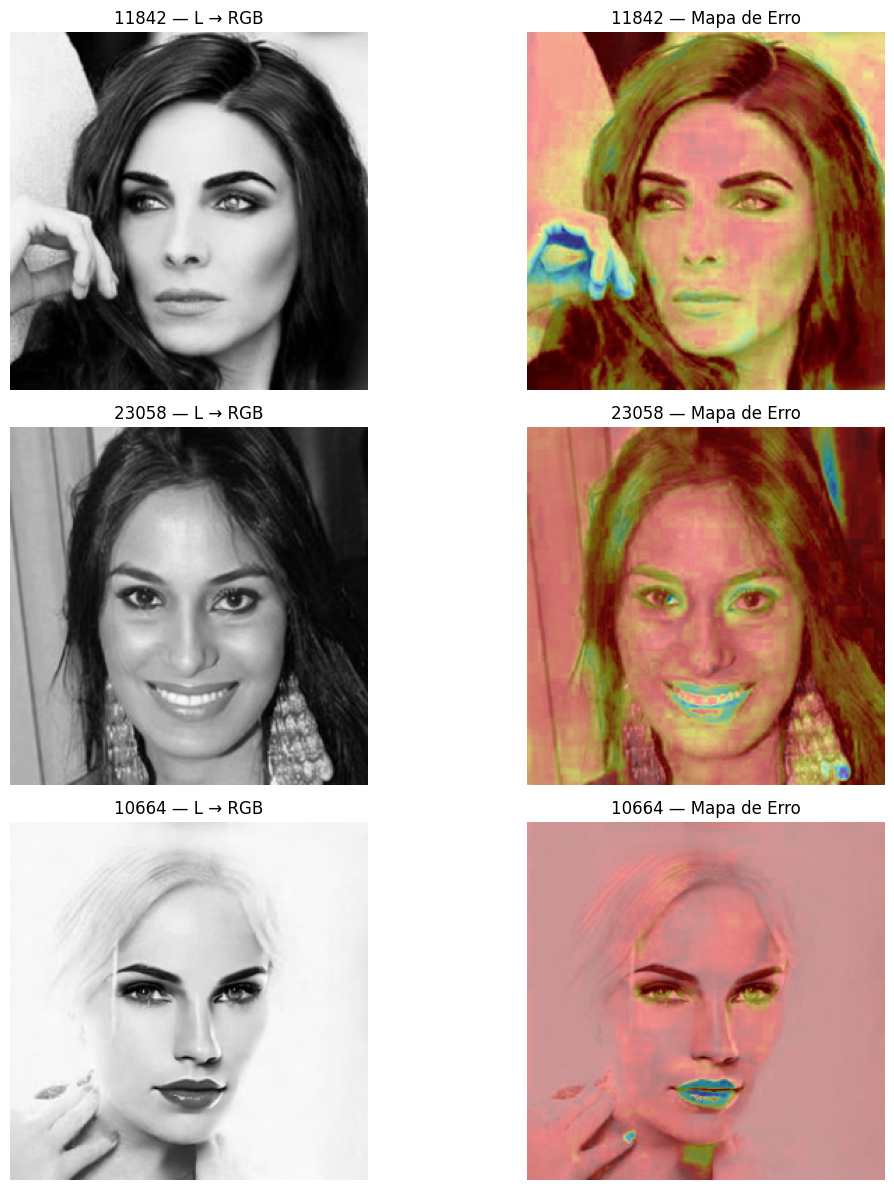

In [26]:
EXAMPLES = 3

fake_out = "/content/drive/MyDrive/Colab Notebooks/RNAP/TP2/outputs/fase3_xai/fake"

overlay_files = sorted([f for f in os.listdir(fake_out) if f.endswith("_overlay.png")])

chosen = random.sample(overlay_files, EXAMPLES)

plt.figure(figsize=(12, 4 * EXAMPLES))

for i, overlay_name in enumerate(chosen):
    base_name = overlay_name.replace("_overlay.png", "")
    bg_name = base_name + "_bg.png"

    bg = Image.open(os.path.join(fake_out, bg_name))
    overlay = Image.open(os.path.join(fake_out, overlay_name))

    plt.subplot(EXAMPLES, 2, 2*i + 1)
    plt.imshow(bg)
    plt.title(f"{base_name} — L → RGB")
    plt.axis("off")

    plt.subplot(EXAMPLES, 2, 2*i + 2)
    plt.imshow(overlay)
    plt.title(f"{base_name} — Mapa de Erro")
    plt.axis("off")

plt.tight_layout()
plt.show()

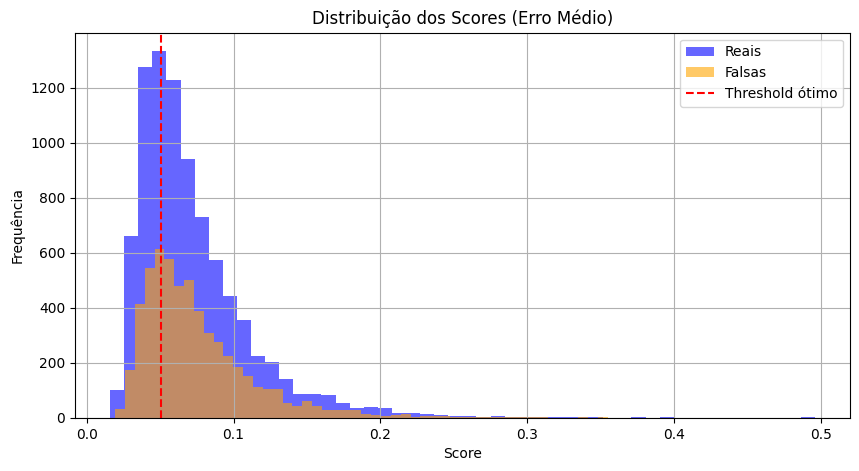

In [27]:
# ==========================================
#  HISTOGRAMA DOS SCORES (ERRO MÉDIO)
# ==========================================

real_scores = scores[labels == 0]
fake_scores = scores[labels == 1]

plt.figure(figsize=(10,5))
plt.hist(real_scores, bins=50, alpha=0.6, label="Reais", color="blue")
plt.hist(fake_scores, bins=50, alpha=0.6, label="Falsas", color="orange")
plt.axvline(opt_threshold, color="red", linestyle="--", label="Threshold ótimo")
plt.title("Distribuição dos Scores (Erro Médio)")
plt.xlabel("Score")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True)
plt.show()